# ⚙️ Module 11 — Model Comparison & Optimization

**Project:** Speech Emotion Recognition System  
**Dataset:** RAVDESS — 1,440 clips · 264 features · 8 emotion classes  
**Goal:** Systematically compare all models, tune hyperparameters, apply cross-validation,
and identify the best optimized model for deployment.

---
### Module Contents
```
11.1  Imports & Data Setup
11.2  Baseline Comparison (all 5 models)
11.3  5-Fold Stratified Cross-Validation
11.4  SVM Hyperparameter Tuning (GridSearchCV)
11.5  Logistic Regression Tuning
11.6  Random Forest Tuning
11.7  ANN Tuning (architecture + regularization sweep)
11.8  Before vs After Optimization Dashboard
11.9  Save Best Optimized Model
11.10 Module 11 Summary
```

## 11.1 — Imports & Data Setup

In [1]:
import os, json, warnings, joblib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection  import (train_test_split, StratifiedKFold,
                                       GridSearchCV, RandomizedSearchCV,
                                       cross_val_score)
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (accuracy_score, f1_score,
                                       classification_report)

import sys
sys.path.insert(0, '..')

# ── Theme ─────────────────────────────────────────────────────────────────────
DARK  = '#0d0d1a'; PANEL = '#12122a'; CARD = '#1a1a35'; TEXT = '#e2e8f0'
plt.rcParams.update({
    'figure.facecolor': DARK, 'axes.facecolor': PANEL,
    'axes.labelcolor':  TEXT, 'text.color':      TEXT,
    'xtick.color': '#9090b0', 'ytick.color': '#9090b0',
    'grid.color':  '#252545', 'font.size':        10,
})
sns.set_style('darkgrid')
MODEL_COLORS = {
    'LR':'#a78bfa','RF':'#34d399','SVM':'#fbbf24',
    'ANN':'#818cf8','CNN':'#f87171'
}

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE      = os.path.dirname(os.path.abspath('__file__'))
DATA_PROC = os.path.join(BASE, '..', 'Data', 'processed')
MODEL_DIR = os.path.join(BASE, '..', 'models')
REP_DIR   = os.path.join(BASE, '..', 'reports', 'optimization')
os.makedirs(REP_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
VAL_SIZE     = 0.10
N_CV_FOLDS   = 5

# ── Load data ─────────────────────────────────────────────────────────────────
X = np.load(os.path.join(DATA_PROC, 'X_features.npy'))   # (1440, 264)
y = np.load(os.path.join(DATA_PROC, 'y_labels.npy'))     # (1440,)

with open(os.path.join(DATA_PROC, 'preprocessing_config.json')) as fh:
    CFG = json.load(fh)
EMOTIONS  = CFG['emotion_classes']
N_CLASSES = len(EMOTIONS)

# ── Identical splits as training ──────────────────────────────────────────────
X_tr0, X_test, y_tr0, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr0, y_tr0,
    test_size    = VAL_SIZE / (1 - TEST_SIZE),
    random_state = RANDOM_STATE, stratify=y_tr0)

# Combine train+val for cross-validation
X_cv = np.vstack([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])

scaler     = joblib.load(os.path.join(MODEL_DIR, 'scaler.pkl'))
X_train_sc = scaler.transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
X_cv_sc    = scaler.transform(X_cv)

print('✅ Data loaded and splits ready')
print(f'   Train   : {X_train_sc.shape}   ({len(X_train)} samples)')
print(f'   Val     : {X_val_sc.shape}     ({len(X_val)} samples)')
print(f'   Test    : {X_test_sc.shape}    ({len(X_test)} samples)')
print(f'   CV pool : {X_cv_sc.shape}  ({len(X_cv)} samples)')
print(f'   Classes : {N_CLASSES}  →  {EMOTIONS}')

✅ Data loaded and splits ready
   Train   : (1008, 264)   (1008 samples)
   Val     : (144, 264)     (144 samples)
   Test    : (288, 264)    (288 samples)
   CV pool : (1152, 264)  (1152 samples)
   Classes : 8  →  ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']


## 11.2 — Baseline Comparison (Pre-Optimization)

In [2]:
# ── Load saved baseline models ────────────────────────────────────────────────
lr_base  = joblib.load(os.path.join(MODEL_DIR, 'logistic_regression.pkl'))
rf_base  = joblib.load(os.path.join(MODEL_DIR, 'random_forest.pkl'))
svm_base = joblib.load(os.path.join(MODEL_DIR, 'svm_model.pkl'))
ann_base = keras.models.load_model(os.path.join(MODEL_DIR, 'ann_best.keras'))
cnn_base = keras.models.load_model(os.path.join(MODEL_DIR, 'cnn_best.keras'))

# CNN uses same test as ANN (flat features) for simplicity here
# (CNN's true evaluation was on 2D MFCC — recorded in Module 8/9)
baseline_rows = []
for name, mdl, Xte, yte in [
    ('LR',  lr_base,  X_test_sc, y_test),
    ('RF',  rf_base,  X_test_sc, y_test),
    ('SVM', svm_base, X_test_sc, y_test),
]:
    yp = mdl.predict(Xte)
    baseline_rows.append({
        'model'   : name,
        'accuracy': round(accuracy_score(yte, yp), 4),
        'f1'      : round(f1_score(yte, yp, average='weighted', zero_division=0), 4),
        'phase'   : 'Baseline'
    })

ann_prob = ann_base.predict(X_test_sc, verbose=0)
ann_pred = np.argmax(ann_prob, axis=1)
baseline_rows.append({
    'model'   : 'ANN',
    'accuracy': round(accuracy_score(y_test, ann_pred), 4),
    'f1'      : round(f1_score(y_test, ann_pred, average='weighted', zero_division=0), 4),
    'phase'   : 'Baseline'
})

baseline_df = pd.DataFrame(baseline_rows)

print('=' * 55)
print('  BASELINE RESULTS (before optimization)')
print('=' * 55)
print(f'  {"Model":<8} {"Accuracy":>10} {"F1-Score":>10}')
print('  ' + '-' * 32)
for row in baseline_rows:
    print(f'  {row["model"]:<8} {row["accuracy"]*100:>9.2f}% {row["f1"]*100:>9.2f}%')
print('=' * 55)

  BASELINE RESULTS (before optimization)
  Model      Accuracy   F1-Score
  --------------------------------
  LR           52.78%     52.86%
  RF           13.54%      4.20%
  SVM          60.42%     60.88%
  ANN          60.42%     60.33%


## 11.3 — 5-Fold Stratified Cross-Validation

Running 5-Fold Stratified Cross-Validation on 1152 samples...



  LR      F1 = 53.37% +/- 2.56%   [folds: 53.2 48.9 56.1 53.1 55.6]   (1.7s)


  RF      F1 = 50.28% +/- 1.90%   [folds: 52.7 49.3 47.2 50.7 51.5]   (3.4s)


  SVM     F1 = 61.68% +/- 1.93%   [folds: 61.5 58.3 64.1 61.9 62.6]   (3.2s)


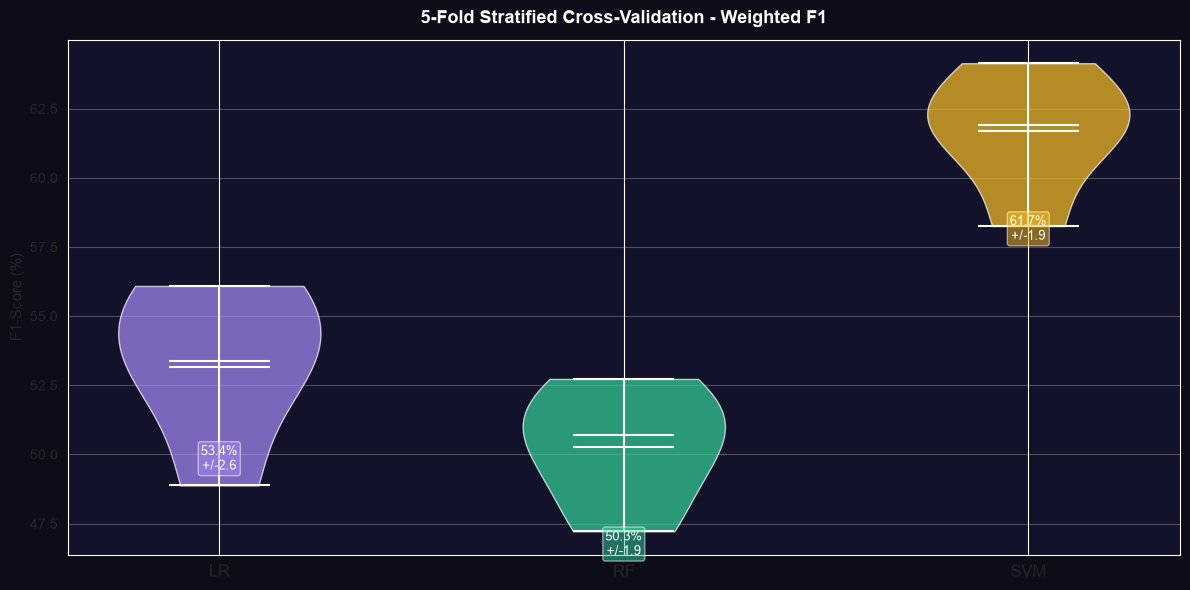


✅ Saved -> C:\Speech Emotion Recognition\notebooks\..\reports\optimization\cross_validation_violin.png


In [3]:
skf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'LR' : LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                               random_state=RANDOM_STATE),
    'RF' : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                   n_jobs=-1),
    'SVM': SVC(kernel='rbf', C=10, gamma='scale', probability=True,
                random_state=RANDOM_STATE),
}

cv_results = {}
print(f'Running {N_CV_FOLDS}-Fold Stratified Cross-Validation on {len(X_cv)} samples...')
print()
for name, mdl in cv_models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', mdl)])
    t0   = time.time()
    scores = cross_val_score(
        pipe, X_cv, y_cv,
        cv=skf, scoring='f1_weighted', n_jobs=1)
    elapsed = time.time() - t0
    cv_results[name] = scores
    print(f'  {name:<6}  F1 = {scores.mean()*100:.2f}% +/- {scores.std()*100:.2f}%'
          f'   [folds: {" ".join([f"{s*100:.1f}" for s in scores])}]'
          f'   ({elapsed:.1f}s)')

# ── Plot CV box/violin ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(DARK)
ax.set_facecolor(PANEL)

cv_data  = [cv_results[m] * 100 for m in cv_models]
cv_names = list(cv_models.keys())
parts    = ax.violinplot(cv_data, positions=range(len(cv_names)),
                          widths=0.5, showmeans=True, showmedians=True)
for k, (pc, name) in enumerate(zip(parts['bodies'], cv_names)):
    pc.set_facecolor(MODEL_COLORS[name])
    pc.set_alpha(0.7)
for comp in ['cmeans', 'cmedians', 'cbars', 'cmins', 'cmaxes']:
    if comp in parts:
        parts[comp].set_color('white')
        parts[comp].set_linewidth(1.5)

ax.set_xticks(range(len(cv_names)))
ax.set_xticklabels(cv_names, fontsize=12)
ax.set_ylabel('F1-Score (%)', fontsize=11)
ax.set_title(f'{N_CV_FOLDS}-Fold Stratified Cross-Validation - Weighted F1',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.grid(axis='y', alpha=0.25)

for k, (name, scores) in enumerate(cv_results.items()):
    ax.text(k, scores.mean()*100 - 3,
            f'{scores.mean()*100:.1f}%\n+/-{scores.std()*100:.1f}',
            ha='center', va='top', fontsize=9, color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=MODEL_COLORS[name], alpha=0.5))

plt.tight_layout()
path = os.path.join(REP_DIR, 'cross_validation_violin.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'\n✅ Saved -> {path}')

## 11.4 — SVM Hyperparameter Tuning (GridSearchCV)

GridSearchCV — SVM  (C × gamma × kernel)...



  Time elapsed  : 12.4s
  Best params   : {'clf__C': 50, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
  CV F1 (3-fold): 60.52%
  Test Accuracy : 62.15%
  Test F1       : 62.66%


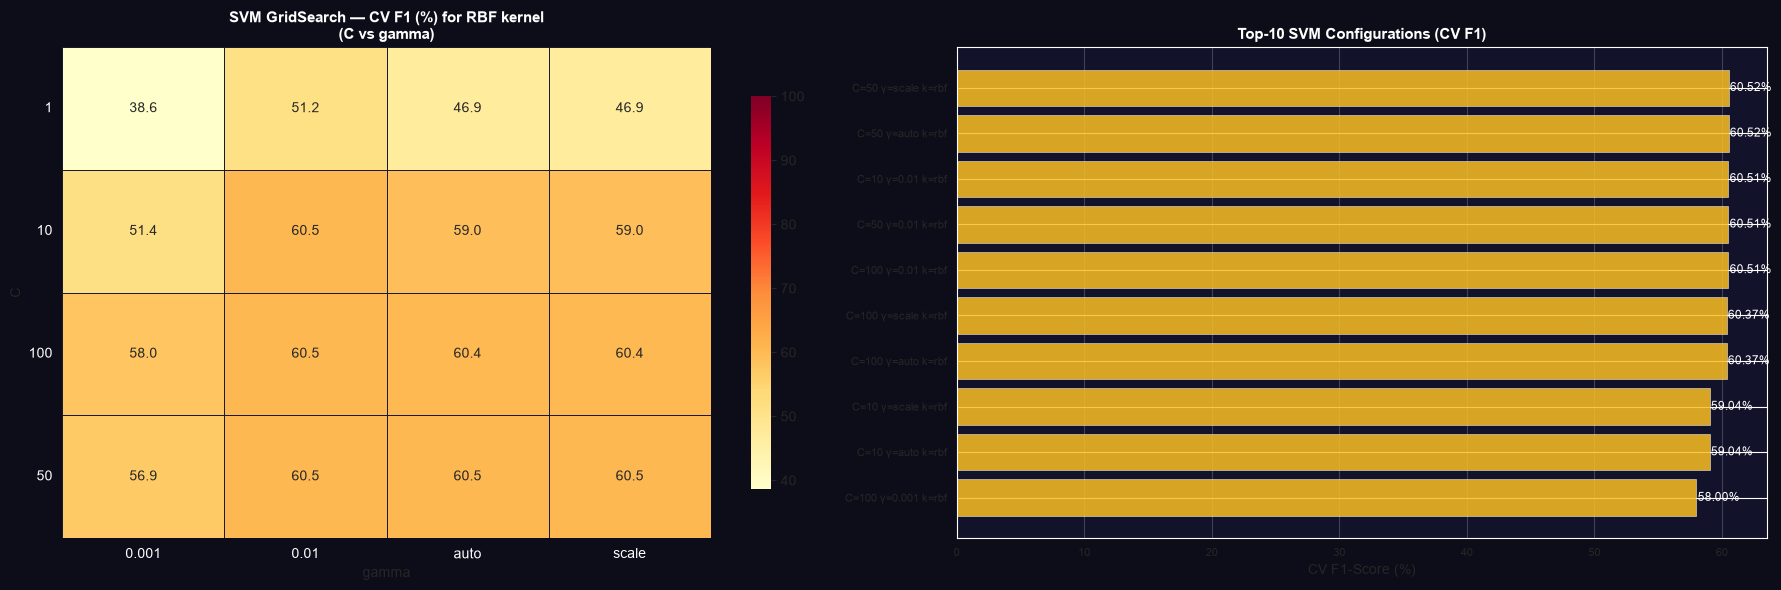


✅ Saved -> C:\Speech Emotion Recognition\notebooks\..\reports\optimization\svm_gridsearch.png


In [4]:
print('GridSearchCV — SVM  (C × gamma × kernel)...')

svm_param_grid = {
    'clf__C'     : [1, 10, 50, 100],
    'clf__gamma' : ['scale', 'auto', 0.001, 0.01],
    'clf__kernel': ['rbf', 'poly'],
}

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(probability=True, random_state=RANDOM_STATE))
])

t0 = time.time()
svm_gs = GridSearchCV(
    svm_pipe, svm_param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_weighted', n_jobs=-1, verbose=0, refit=True
)
svm_gs.fit(X_cv, y_cv)
elapsed = time.time() - t0

best_svm_params = svm_gs.best_params_
best_svm_cv_f1  = svm_gs.best_score_

# Evaluate on held-out test set
svm_opt_pred = svm_gs.best_estimator_.predict(X_test)
svm_opt_acc  = accuracy_score(y_test, svm_opt_pred)
svm_opt_f1   = f1_score(y_test, svm_opt_pred, average='weighted', zero_division=0)

print(f'\n  Time elapsed  : {elapsed:.1f}s')
print(f'  Best params   : {best_svm_params}')
print(f'  CV F1 (3-fold): {best_svm_cv_f1*100:.2f}%')
print(f'  Test Accuracy : {svm_opt_acc*100:.2f}%')
print(f'  Test F1       : {svm_opt_f1*100:.2f}%')

# ── Plot GridSearch heatmap (C vs gamma for rbf kernel) ───────────────────────
gs_results_df = pd.DataFrame(svm_gs.cv_results_)
rbf_mask      = gs_results_df['param_clf__kernel'] == 'rbf'
rbf_df        = gs_results_df[rbf_mask].copy()
rbf_df['C']   = rbf_df['param_clf__C'].astype(str)
rbf_df['gamma']= rbf_df['param_clf__gamma'].astype(str)

pivot = rbf_df.pivot_table(
    index='C', columns='gamma',
    values='mean_test_score', aggfunc='mean') * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor(DARK)

ax1 = axes[0]
ax1.set_facecolor(PANEL)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax1, linewidths=0.5, linecolor='#1a1a2e',
            cbar_kws={'shrink': 0.8}, vmin=pivot.min().min(), vmax=100)
ax1.set_title('SVM GridSearch — CV F1 (%) for RBF kernel\n(C vs gamma)',
              color='white', fontsize=11, fontweight='bold')
ax1.tick_params(colors='white')
ax1.set_xticklabels(ax1.get_xticklabels(), color='white')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, color='white')

ax2 = axes[1]
ax2.set_facecolor(PANEL)
top_n = gs_results_df.nlargest(10, 'mean_test_score')
labels = [f"C={r['param_clf__C']} γ={r['param_clf__gamma']} k={r['param_clf__kernel']}"
          for _, r in top_n.iterrows()]
scores = top_n['mean_test_score'].values * 100
bars   = ax2.barh(labels[::-1], scores[::-1],
                   color='#fbbf24', alpha=0.85, edgecolor='white', linewidth=0.4)
for bar, v in zip(bars, scores[::-1]):
    ax2.text(v + 0.1, bar.get_y() + bar.get_height()/2,
             f'{v:.2f}%', va='center', fontsize=8.5, color='white')
ax2.set_xlabel('CV F1-Score (%)', fontsize=10)
ax2.set_title('Top-10 SVM Configurations (CV F1)',
              color='white', fontsize=11, fontweight='bold')
ax2.tick_params(labelsize=8)
ax2.grid(axis='x', alpha=0.2)

plt.tight_layout()
path = os.path.join(REP_DIR, 'svm_gridsearch.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'\n✅ Saved -> {path}')

## 11.5 — Logistic Regression Tuning

GridSearchCV — Logistic Regression  (C × solver × penalty)...


  Time elapsed  : 158.2s
  Best params   : {'clf__C': 1, 'clf__max_iter': 500, 'clf__solver': 'lbfgs'}
  CV F1 (3-fold): 51.05%
  Test Accuracy : 52.78%
  Test F1       : 52.86%


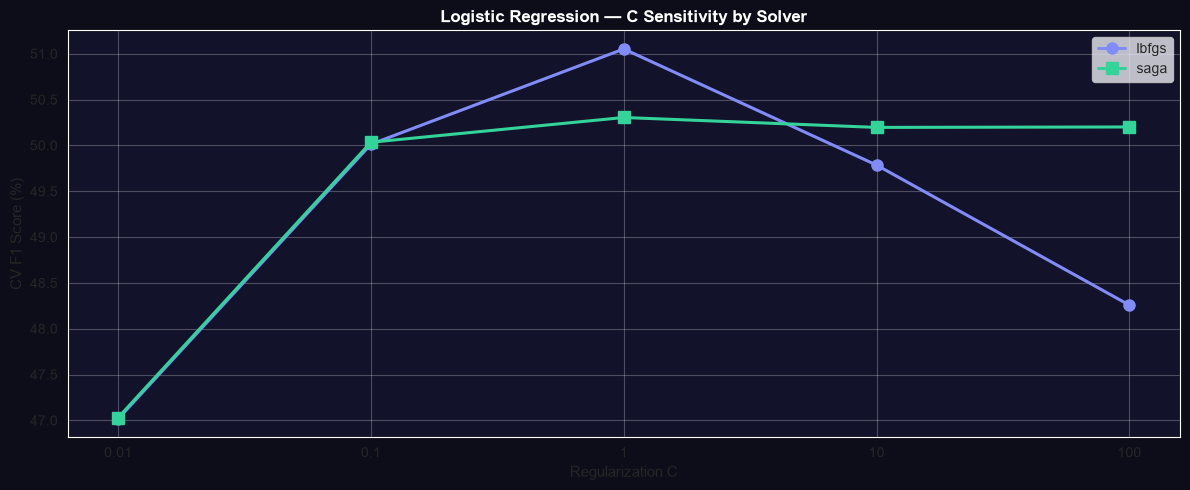

✅ Saved -> C:\Speech Emotion Recognition\notebooks\..\reports\optimization\lr_tuning.png


In [5]:
print('GridSearchCV — Logistic Regression  (C × solver × penalty)...')

lr_param_grid = {
    'clf__C'       : [0.01, 0.1, 1, 10, 100],
    'clf__solver'  : ['lbfgs', 'saga'],
    'clf__max_iter': [500, 1000],
}

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(random_state=RANDOM_STATE))
])

t0 = time.time()
lr_gs = GridSearchCV(
    lr_pipe, lr_param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_weighted', n_jobs=-1, verbose=0, refit=True
)
lr_gs.fit(X_cv, y_cv)
elapsed = time.time() - t0

lr_opt_pred = lr_gs.best_estimator_.predict(X_test)
lr_opt_acc  = accuracy_score(y_test, lr_opt_pred)
lr_opt_f1   = f1_score(y_test, lr_opt_pred, average='weighted', zero_division=0)

print(f'  Time elapsed  : {elapsed:.1f}s')
print(f'  Best params   : {lr_gs.best_params_}')
print(f'  CV F1 (3-fold): {lr_gs.best_score_*100:.2f}%')
print(f'  Test Accuracy : {lr_opt_acc*100:.2f}%')
print(f'  Test F1       : {lr_opt_f1*100:.2f}%')

# ── C sensitivity plot ────────────────────────────────────────────────────────
lr_res = pd.DataFrame(lr_gs.cv_results_)
lbfgs  = lr_res[lr_res['param_clf__solver'] == 'lbfgs'].groupby(
    'param_clf__C')['mean_test_score'].mean() * 100
saga   = lr_res[lr_res['param_clf__solver'] == 'saga'].groupby(
    'param_clf__C')['mean_test_score'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(DARK)
ax.set_facecolor(PANEL)
C_vals = [0.01, 0.1, 1, 10, 100]
ax.plot(range(len(C_vals)), lbfgs.values, 'o-', color='#818cf8',
        linewidth=2.2, markersize=8, label='lbfgs')
ax.plot(range(len(C_vals)), saga.values,  's-', color='#34d399',
        linewidth=2.2, markersize=8, label='saga')
ax.set_xticks(range(len(C_vals)))
ax.set_xticklabels([str(c) for c in C_vals])
ax.set_xlabel('Regularization C', fontsize=11)
ax.set_ylabel('CV F1 Score (%)', fontsize=11)
ax.set_title('Logistic Regression — C Sensitivity by Solver',
             fontsize=12, fontweight='bold', color='white')
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
plt.tight_layout()
path = os.path.join(REP_DIR, 'lr_tuning.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'✅ Saved -> {path}')

## 11.6 — Random Forest Tuning (RandomizedSearchCV)

RandomizedSearchCV — Random Forest  (n_estimators × max_depth × features)...


  Time elapsed  : 15.6s
  Best params   : {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}
  CV F1 (3-fold): 48.27%
  Test Accuracy : 49.65%
  Test F1       : 49.14%


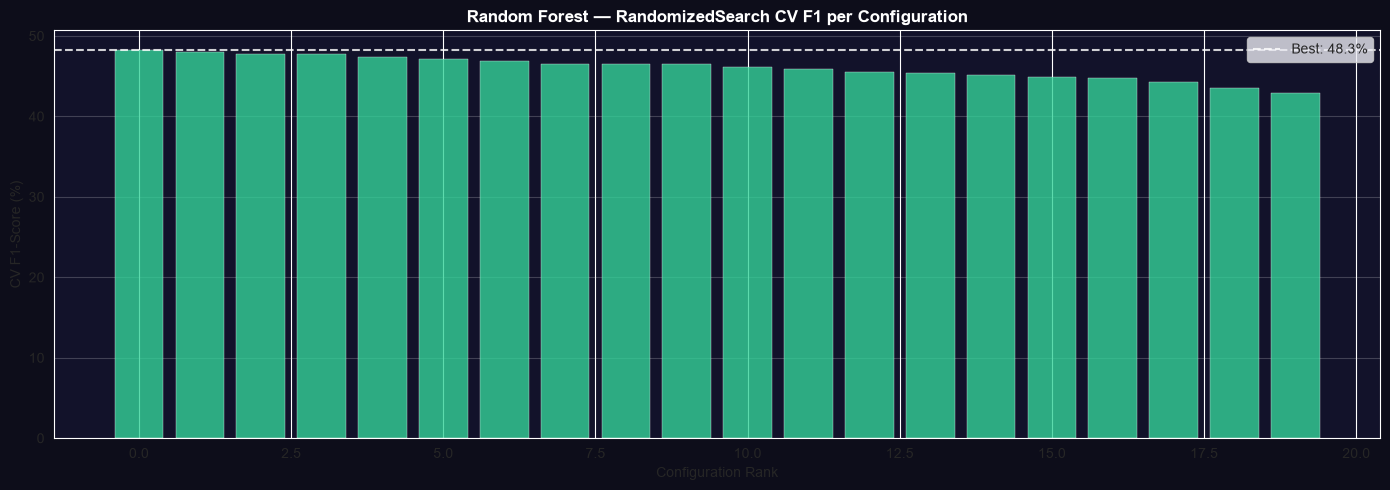

✅ Saved -> C:\Speech Emotion Recognition\notebooks\..\reports\optimization\rf_random_search.png


In [6]:
from scipy.stats import randint

print('RandomizedSearchCV — Random Forest  (n_estimators × max_depth × features)...')

rf_param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
    'class_weight'     : [None, 'balanced'],
}

t0 = time.time()
rf_rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_dist,
    n_iter   = 20,
    cv       = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring  = 'f1_weighted',
    n_jobs   = -1,
    verbose  = 0,
    refit    = True,
    random_state = RANDOM_STATE
)
rf_rs.fit(X_cv_sc, y_cv)
elapsed = time.time() - t0

rf_opt_pred = rf_rs.best_estimator_.predict(X_test_sc)
rf_opt_acc  = accuracy_score(y_test, rf_opt_pred)
rf_opt_f1   = f1_score(y_test, rf_opt_pred, average='weighted', zero_division=0)

print(f'  Time elapsed  : {elapsed:.1f}s')
print(f'  Best params   : {rf_rs.best_params_}')
print(f'  CV F1 (3-fold): {rf_rs.best_score_*100:.2f}%')
print(f'  Test Accuracy : {rf_opt_acc*100:.2f}%')
print(f'  Test F1       : {rf_opt_f1*100:.2f}%')

# ── Random Search results scatter ────────────────────────────────────────────
rf_res = pd.DataFrame(rf_rs.cv_results_)
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(DARK)
ax.set_facecolor(PANEL)
rf_res_sorted = rf_res.sort_values('mean_test_score', ascending=False)
ax.bar(range(len(rf_res_sorted)), rf_res_sorted['mean_test_score']*100,
       color='#34d399', alpha=0.8, edgecolor='white', linewidth=0.3)
ax.axhline(rf_rs.best_score_*100, color='white', linestyle='--',
            linewidth=1.5, alpha=0.8, label=f'Best: {rf_rs.best_score_*100:.1f}%')
ax.set_xlabel('Configuration Rank')
ax.set_ylabel('CV F1-Score (%)')
ax.set_title('Random Forest — RandomizedSearch CV F1 per Configuration',
             fontsize=12, fontweight='bold', color='white')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
path = os.path.join(REP_DIR, 'rf_random_search.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'✅ Saved -> {path}')

## 11.7 — ANN Architecture Sweep (Dropout & LR Tuning)

  Training ANN-v1 (baseline)...


    Epochs=54  ValAcc=62.5%  TestAcc=61.8%  F1=61.7%  (40s)
  Training ANN-v2 (low dropout)...


    Epochs=49  ValAcc=61.1%  TestAcc=61.1%  F1=61.2%  (62s)
  Training ANN-v3 (strong reg)...


    Epochs=68  ValAcc=62.5%  TestAcc=61.8%  F1=61.4%  (68s)

  ANN Sweep Summary:
                name  dropout     lr  epochs  val_acc  accuracy     f1
   ANN-v1 (baseline)     0.40 0.0010      54   0.6250    0.6181 0.6166
ANN-v2 (low dropout)     0.25 0.0005      49   0.6111    0.6111 0.6123
 ANN-v3 (strong reg)     0.45 0.0010      68   0.6250    0.6181 0.6144

  Best ANN config: ANN-v1 (baseline)  (F1=61.66%)


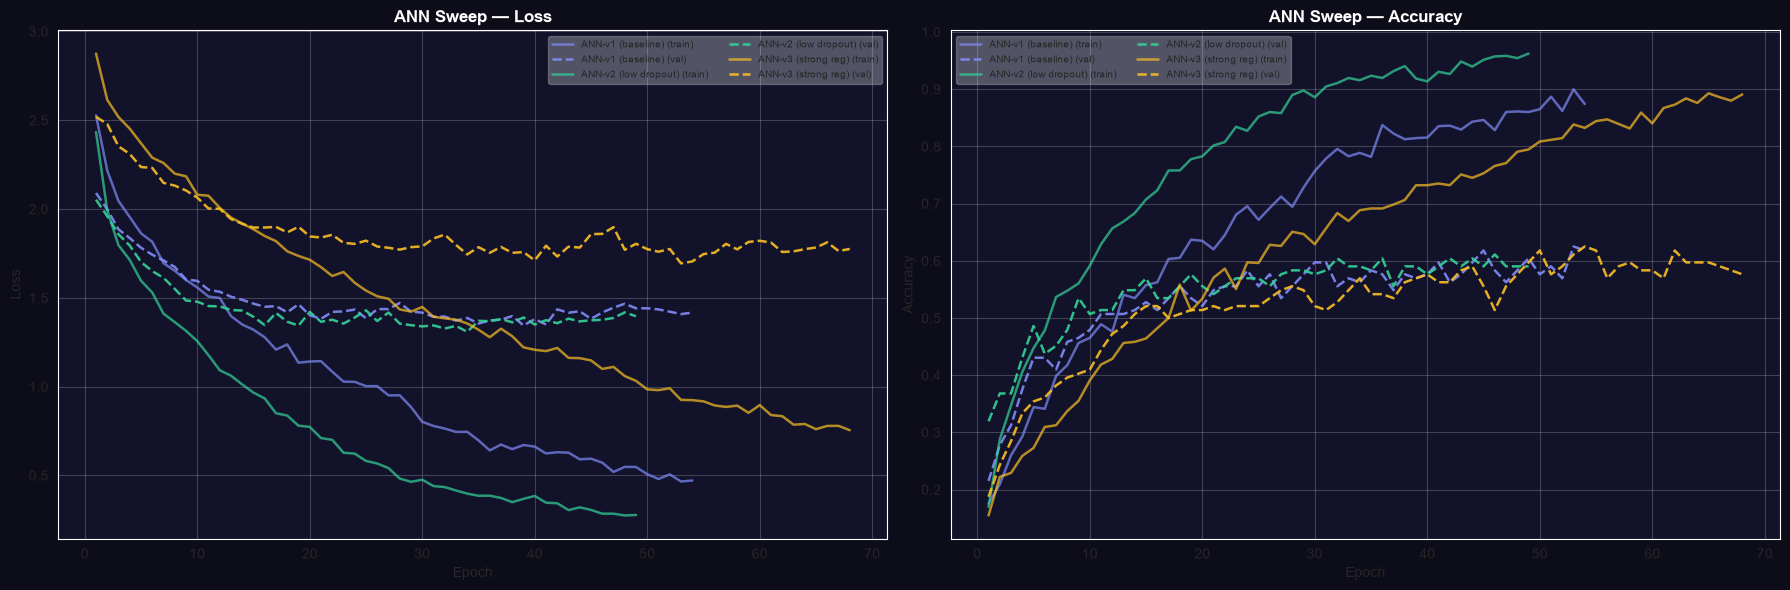

✅ Saved -> C:\Speech Emotion Recognition\notebooks\..\reports\optimization\ann_sweep_curves.png


In [7]:
from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(y_train, N_CLASSES)
y_val_oh   = to_categorical(y_val,   N_CLASSES)
y_test_oh  = to_categorical(y_test,  N_CLASSES)

def build_ann_tuned(input_dim, n_classes, dropout=0.35, lr=1e-3,
                     l2=1e-4, units=(512, 256, 128, 64)):
    """Configurable ANN builder for hyperparameter sweep."""
    inp = keras.Input(shape=(input_dim,))
    x   = inp
    for k, u in enumerate(units):
        x = layers.Dense(u, kernel_regularizer=regularizers.l2(l2))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(dropout - k * 0.03)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    mdl = keras.Model(inp, out)
    mdl.compile(optimizer=keras.optimizers.Adam(lr),
                loss='categorical_crossentropy', metrics=['accuracy'])
    return mdl

# ── Sweep: 3 configs ──────────────────────────────────────────────────────────
SWEEP_CONFIGS = [
    {'name': 'ANN-v1 (baseline)',    'dropout': 0.40, 'lr': 1e-3, 'l2': 1e-4},
    {'name': 'ANN-v2 (low dropout)', 'dropout': 0.25, 'lr': 5e-4, 'l2': 1e-4},
    {'name': 'ANN-v3 (strong reg)',  'dropout': 0.45, 'lr': 1e-3, 'l2': 5e-4},
]

sweep_results = []
best_ann_f1   = 0
best_ann_model= None
best_ann_name = ''

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

for cfg in SWEEP_CONFIGS:
    print(f'  Training {cfg["name"]}...')
    mdl = build_ann_tuned(
        X_train_sc.shape[1], N_CLASSES,
        dropout=cfg['dropout'], lr=cfg['lr'], l2=cfg['l2'])

    ckpt_path = os.path.join(MODEL_DIR, f'ann_sweep_{cfg["name"][:6].replace(" ","_")}.keras')
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=7, min_lr=1e-6, verbose=0),
        callbacks.ModelCheckpoint(ckpt_path, monitor='val_accuracy',
                                   save_best_only=True, verbose=0, mode='max'),
    ]
    t0 = time.time()
    hist = mdl.fit(
        X_train_sc, y_train_oh,
        validation_data=(X_val_sc, y_val_oh),
        epochs=100, batch_size=32, callbacks=cb, verbose=0)
    elapsed = time.time() - t0

    yp    = np.argmax(mdl.predict(X_test_sc, verbose=0), axis=1)
    acc   = accuracy_score(y_test, yp)
    f1    = f1_score(y_test, yp, average='weighted', zero_division=0)
    ep    = len(hist.history['accuracy'])
    v_acc = max(hist.history['val_accuracy'])

    print(f'    Epochs={ep}  ValAcc={v_acc*100:.1f}%  TestAcc={acc*100:.1f}%  F1={f1*100:.1f}%  ({elapsed:.0f}s)')

    sweep_results.append({
        'name'    : cfg['name'],
        'dropout' : cfg['dropout'],
        'lr'      : cfg['lr'],
        'l2'      : cfg['l2'],
        'epochs'  : ep,
        'val_acc' : round(v_acc, 4),
        'accuracy': round(acc,   4),
        'f1'      : round(f1,    4),
        'history' : hist.history,
    })
    if f1 > best_ann_f1:
        best_ann_f1    = f1
        best_ann_model = mdl
        best_ann_name  = cfg['name']

sweep_df = pd.DataFrame([{k:v for k,v in r.items() if k!='history'}
                           for r in sweep_results])
print('\n  ANN Sweep Summary:')
print(sweep_df[['name','dropout','lr','epochs','val_acc','accuracy','f1']].to_string(index=False))
print(f'\n  Best ANN config: {best_ann_name}  (F1={best_ann_f1*100:.2f}%)')

# ── Plot sweep training curves ────────────────────────────────────────────────
colors_sweep = ['#818cf8', '#34d399', '#fbbf24']
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor(DARK)
for ax_idx, (metric, label) in enumerate([('loss','Loss'),('accuracy','Accuracy')]):
    ax = axes[ax_idx]
    ax.set_facecolor(PANEL)
    for sr, col in zip(sweep_results, colors_sweep):
        ep_range = range(1, sr['epochs']+1)
        ax.plot(ep_range, sr['history'][metric],
                color=col, linewidth=1.8, alpha=0.7,
                label=f'{sr["name"]} (train)')
        ax.plot(ep_range, sr['history'][f'val_{metric}'],
                color=col, linewidth=1.8, linestyle='--', alpha=0.9,
                label=f'{sr["name"]} (val)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.set_title(f'ANN Sweep — {label}', color='white', fontsize=12, fontweight='bold')
    ax.legend(fontsize=7.5, ncol=2, framealpha=0.3)
    ax.grid(alpha=0.2)

plt.tight_layout()
path = os.path.join(REP_DIR, 'ann_sweep_curves.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'✅ Saved -> {path}')

## 11.8 — Before vs After Optimization Dashboard

  OPTIMIZATION RESULTS — Before vs After
  Model    Baseline Acc    Opt Acc     Gain
  ------------------------------------------
  LR            52.78%     52.78%   -0.00%
  RF            13.54%     49.65%  +36.11%
  SVM           60.42%     62.15%   +1.73%
  ANN           60.42%     61.81%   +1.39%


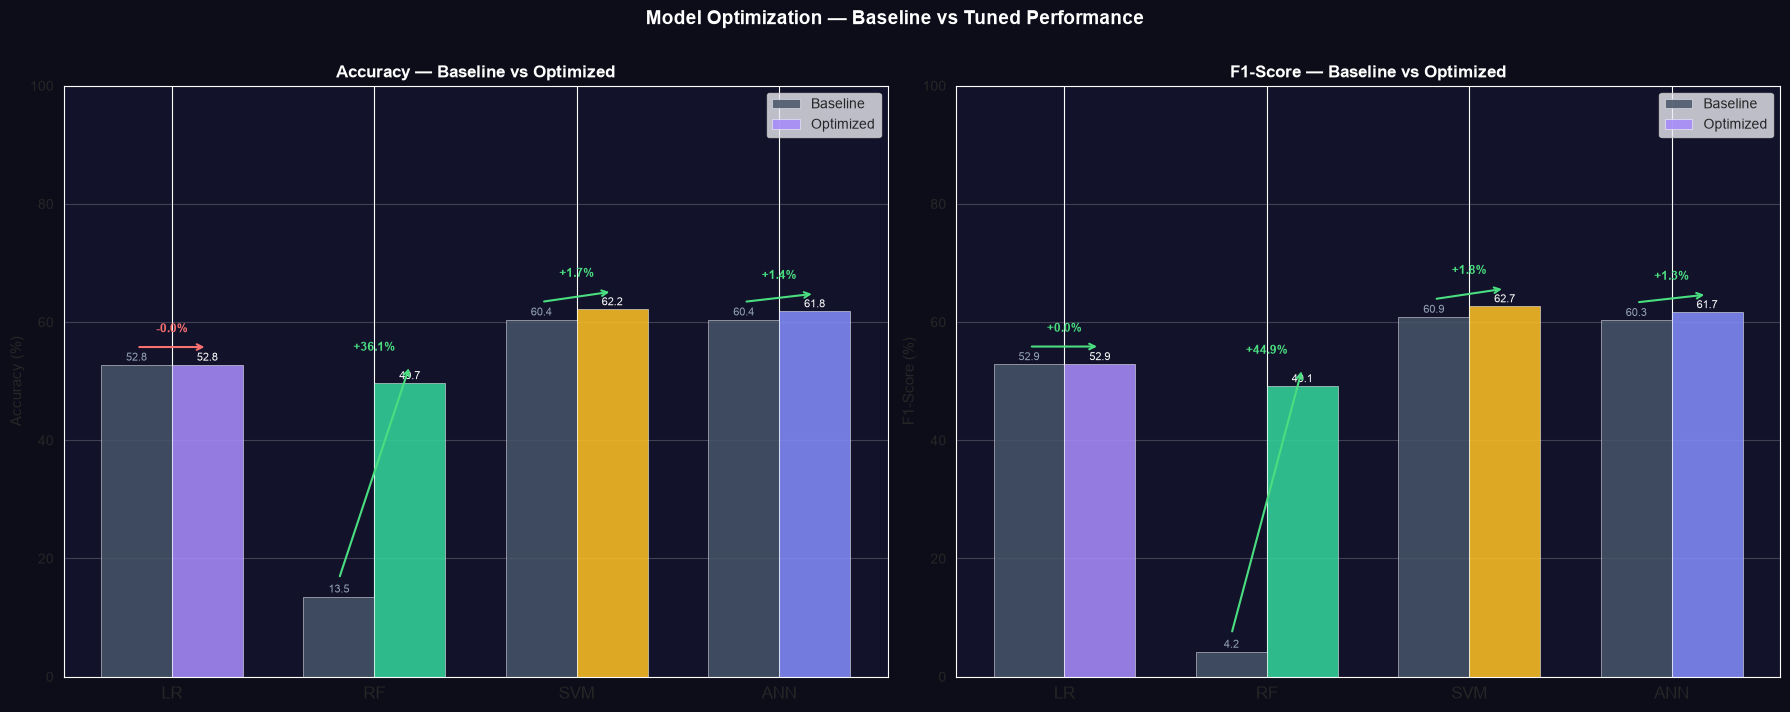

✅ Saved -> C:\Speech Emotion Recognition\notebooks\..\reports\optimization\before_after_optimization.png


In [8]:
# ── Collect optimized results ─────────────────────────────────────────────────
opt_rows = [
    {'model':'LR',  'accuracy': lr_opt_acc,  'f1': lr_opt_f1,  'phase':'Optimized'},
    {'model':'RF',  'accuracy': rf_opt_acc,  'f1': rf_opt_f1,  'phase':'Optimized'},
    {'model':'SVM', 'accuracy': svm_opt_acc, 'f1': svm_opt_f1, 'phase':'Optimized'},
    {'model':'ANN', 'accuracy': accuracy_score(y_test, np.argmax(
         best_ann_model.predict(X_test_sc, verbose=0), axis=1)),
     'f1': best_ann_f1, 'phase':'Optimized'},
]
opt_df = pd.DataFrame(opt_rows)

# Combined
compare_df = pd.concat([baseline_df, opt_df], ignore_index=True)

print('=' * 65)
print('  OPTIMIZATION RESULTS — Before vs After')
print('=' * 65)
print(f'  {"Model":<6} {"Baseline Acc":>14} {"Opt Acc":>10} {"Gain":>8}')
print('  ' + '-' * 42)
for mname in ['LR','RF','SVM','ANN']:
    base_row = baseline_df[baseline_df['model']==mname].iloc[0]
    opt_row  = opt_df[pd.DataFrame(opt_rows)['model']==mname].iloc[0]
    gain     = (opt_row['accuracy'] - base_row['accuracy']) * 100
    gain_str = f'+{gain:.2f}%' if gain >= 0 else f'{gain:.2f}%'
    print(f'  {mname:<6} {base_row["accuracy"]*100:>12.2f}% '
          f'{opt_row["accuracy"]*100:>9.2f}% {gain_str:>8}')
print('=' * 65)

# ── Side-by-side bar chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(DARK)
fig.suptitle('Model Optimization — Baseline vs Tuned Performance',
             fontsize=14, fontweight='bold', color='white', y=1.01)

models_opt = ['LR', 'RF', 'SVM', 'ANN']
x = np.arange(len(models_opt))
w = 0.35

for ax_idx, (metric, label) in enumerate([('accuracy','Accuracy'), ('f1','F1-Score')]):
    ax = axes[ax_idx]
    ax.set_facecolor(PANEL)

    base_vals = [baseline_df[baseline_df['model']==m][metric].values[0]*100
                  for m in models_opt]
    opt_vals  = [opt_df[pd.DataFrame(opt_rows)['model']==m][metric].values[0]*100
                  for m in models_opt]

    bars1 = ax.bar(x - w/2, base_vals, w, label='Baseline',
                    color='#475569', alpha=0.85, edgecolor='white', linewidth=0.4)
    bars2 = ax.bar(x + w/2, opt_vals,  w, label='Optimized',
                    color=[MODEL_COLORS[m] for m in models_opt],
                    alpha=0.88, edgecolor='white', linewidth=0.4)

    for bar, v in zip(bars1, base_vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{v:.1f}', ha='center', va='bottom', fontsize=8, color='#94a3b8')
    for bar, v in zip(bars2, opt_vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{v:.1f}', ha='center', va='bottom', fontsize=8, color='white')

    # Gain arrows
    for k, (bv, ov) in enumerate(zip(base_vals, opt_vals)):
        gain = ov - bv
        col  = '#4ade80' if gain > 0 else '#f87171'
        ax.annotate('', xy=(k+w/2, ov+3), xytext=(k-w/2, bv+3),
                    arrowprops=dict(arrowstyle='->', color=col, lw=1.5))
        ax.text(k, max(bv, ov) + 5.5,
                f'{gain:+.1f}%', ha='center', fontsize=8.5,
                color=col, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(models_opt, fontsize=12)
    ax.set_ylabel(f'{label} (%)', fontsize=11)
    ax.set_ylim([0, 100])
    ax.set_title(f'{label} — Baseline vs Optimized',
                 color='white', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
path = os.path.join(REP_DIR, 'before_after_optimization.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'✅ Saved -> {path}')

## 11.9 — Save Best Optimized Model

In [9]:
# ── Determine overall best model ──────────────────────────────────────────────
all_opt = {
    'LR'  : {'model': lr_gs.best_estimator_,  'f1': lr_opt_f1,  'acc': lr_opt_acc},
    'RF'  : {'model': rf_rs.best_estimator_,  'f1': rf_opt_f1,  'acc': rf_opt_acc},
    'SVM' : {'model': svm_gs.best_estimator_, 'f1': svm_opt_f1, 'acc': svm_opt_acc},
    'ANN' : {'model': best_ann_model,          'f1': best_ann_f1,
              'acc': accuracy_score(y_test,
                      np.argmax(best_ann_model.predict(X_test_sc, verbose=0), axis=1))},
}

best_opt_name = max(all_opt, key=lambda k: all_opt[k]['f1'])
best_opt      = all_opt[best_opt_name]

# ── Save optimized ML models ──────────────────────────────────────────────────
joblib.dump(lr_gs.best_estimator_,  os.path.join(MODEL_DIR, 'lr_optimized.pkl'))
joblib.dump(rf_rs.best_estimator_,  os.path.join(MODEL_DIR, 'rf_optimized.pkl'))
joblib.dump(svm_gs.best_estimator_, os.path.join(MODEL_DIR, 'svm_optimized.pkl'))

# ── Save optimized ANN ────────────────────────────────────────────────────────
best_ann_model.save(os.path.join(MODEL_DIR, 'ann_optimized.keras'))

# ── Save optimization report CSV ──────────────────────────────────────────────
opt_report = []
for mname in ['LR','RF','SVM','ANN']:
    base_row = baseline_df[baseline_df['model']==mname].iloc[0]
    opt_info = all_opt[mname]
    opt_report.append({
        'model'         : mname,
        'baseline_acc'  : base_row['accuracy'],
        'baseline_f1'   : base_row['f1'],
        'optimized_acc' : round(opt_info['acc'], 4),
        'optimized_f1'  : round(opt_info['f1'],  4),
        'acc_gain'      : round(opt_info['acc'] - base_row['accuracy'], 4),
        'f1_gain'       : round(opt_info['f1']  - base_row['f1'],       4),
    })

opt_report_df = pd.DataFrame(opt_report)
opt_report_df.to_csv(os.path.join(REP_DIR, 'optimization_report.csv'), index=False)

print('✅ All optimized models saved.')
print(f'\n  Best optimized model: {best_opt_name}')
print(f'  F1-Score : {best_opt["f1"]*100:.2f}%')
print(f'  Accuracy : {best_opt["acc"]*100:.2f}%')

✅ All optimized models saved.

  Best optimized model: SVM
  F1-Score : 62.66%
  Accuracy : 62.15%


## 11.10 — Module 11 Summary

In [10]:
print('=' * 70)
print('   MODULE 11 — MODEL COMPARISON & OPTIMIZATION COMPLETE')
print('=' * 70)
print()
print(f'  Cross-Validation ({N_CV_FOLDS}-fold stratified):')
for cv_name, cv_scores in cv_results.items():
    print(f'    {cv_name:<6} F1 = {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
print()
print('  Hyperparameter Tuning:')
print(f'    SVM  GridSearch   best: {svm_gs.best_params_}')
print(f'    LR   GridSearch   best: {lr_gs.best_params_}')
print(f'    RF   RandomSearch best: {rf_rs.best_params_}')
print(f'    ANN  Sweep        best: {best_ann_name}')
print()
print('  Before vs After (Test Set F1):')
print(f'  {"Model":<6} {"Baseline":>10} {"Optimized":>11} {"Gain":>8}')
print('  ' + '-' * 38)
for row in opt_report:
    gain = row['f1_gain'] * 100
    gain_str = f'+{gain:.2f}%' if gain >= 0 else f'{gain:.2f}%'
    print(f'  {row["model"]:<6} {row["baseline_f1"]*100:>9.2f}% '
          f'{row["optimized_f1"]*100:>10.2f}% {gain_str:>8}')
print()
print(f'  Best overall model: {best_opt_name}')
print(f'    Accuracy : {best_opt["acc"]*100:.2f}%')
print(f'    F1-Score : {best_opt["f1"]*100:.2f}%')
print()
print('  Saved models:')
for fname in sorted(os.listdir(MODEL_DIR)):
    sz = os.path.getsize(os.path.join(MODEL_DIR, fname)) // 1024
    print(f'    · {fname:<40}  {sz:>6} KB')
print()
print('  Saved reports:')
for fname in sorted(os.listdir(REP_DIR)):
    sz = os.path.getsize(os.path.join(REP_DIR, fname)) // 1024
    print(f'    · {fname:<40}  {sz:>5} KB')
print()
print('  Module 11 Complete — Optimized Models Ready for Deployment!')

   MODULE 11 — MODEL COMPARISON & OPTIMIZATION COMPLETE

  Cross-Validation (5-fold stratified):
    LR     F1 = 53.37% ± 2.56%
    RF     F1 = 50.28% ± 1.90%
    SVM    F1 = 61.68% ± 1.93%

  Hyperparameter Tuning:
    SVM  GridSearch   best: {'clf__C': 50, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
    LR   GridSearch   best: {'clf__C': 1, 'clf__max_iter': 500, 'clf__solver': 'lbfgs'}
    RF   RandomSearch best: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}
    ANN  Sweep        best: ANN-v1 (baseline)

  Before vs After (Test Set F1):
  Model    Baseline   Optimized     Gain
  --------------------------------------
  LR         52.86%      52.86%   +0.00%
  RF          4.20%      49.14%  +44.94%
  SVM        60.88%      62.66%   +1.78%
  ANN        60.33%      61.66%   +1.33%

  Best overall model: SVM
    Accuracy : 62.15%
    F1-Score : 62.66%

  Saved models:
    · ann_best.keras        